<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/HHM/HHM_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install hmmlearn



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.7 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn import hmm
import matplotlib.pyplot as plt

/tmp/ipykernel_3772/4292981818.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Fetching data for QQQ...
Training 3-State HMM on QQQ daily log returns...



STATE CHARACTERISTICS FOR QQQ

State 0:
  Expected Daily Log Return (Mean): 0.002505
  Expected Percent Return (Mean): 0.2508%
  Daily Volatility (Std Dev):     0.009125
  Days spent in this state:       1334 (66.4%)

State 1:
  Expected Daily Log Return (Mean): -0.004796
  Expected Percent Return (Mean): -0.4784%
  Daily Volatility (Std Dev):     0.016863
  Days spent in this state:       66 (3.3%)

State 2:
  Expected Daily Log Return (Mean): -0.001432
  Expected Percent Return (Mean): -0.1431%
  Daily Volatility (Std Dev):     0.024538
  Days spent in this state:       610 (30.3%)

Transition Probability Matrix (in %):
  From State 0: 83.12% 16.88% 0.00% 
  From State 1: 93.91% 0.14% 5.95% 
  From State 2: 1.99% 0.52% 97.50% 


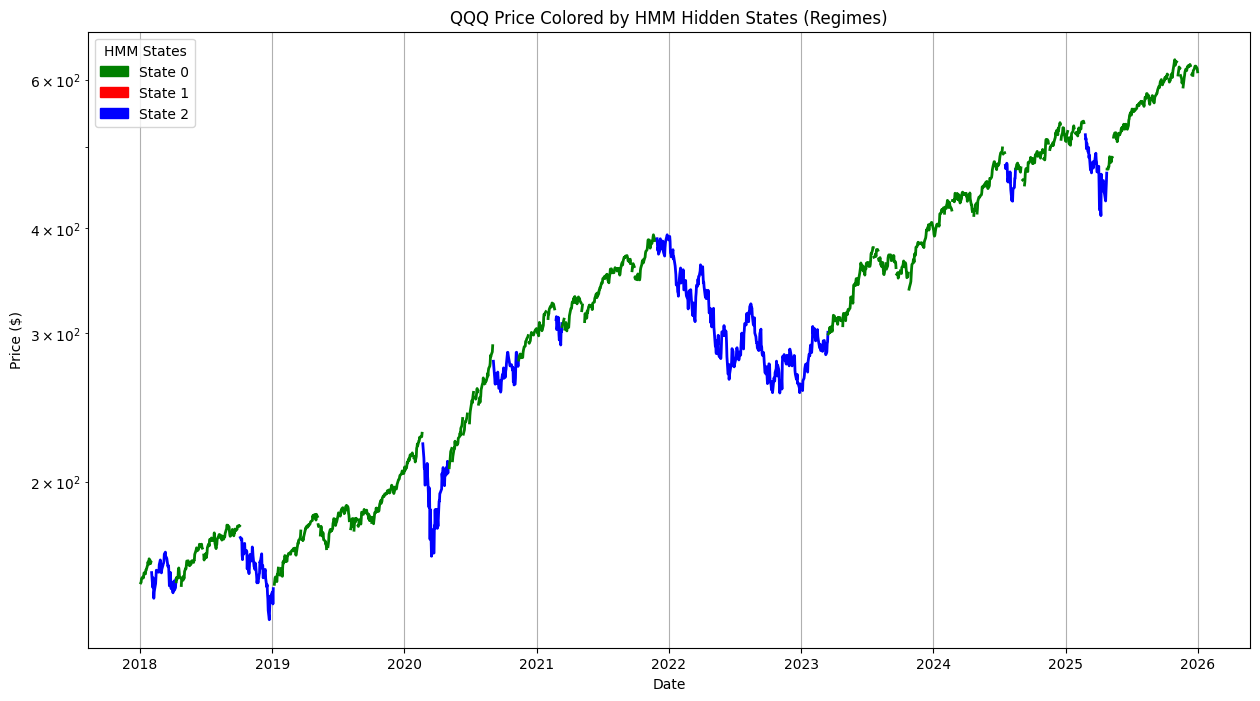

In [11]:
# ==========================================
# 1. CONFIGURATION & VARIABLE SETUP
# ==========================================
# Change this variable to "SPY", "IWM", or "QQQ"
TICKER = "QQQ"

START_DATE = "2018-01-01"
END_DATE = "2026-01-01"  # Adjust based on your preferred backtest window
N_STATES = 3

# ==========================================
# 2. DATA ACQUISITION & PREPROCESSING
# ==========================================
print(f"Fetching data for {TICKER}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# Calculate Daily Log Returns
# log(Rt) = log(Pt / Pt-1)
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

# Reshape data for hmmlearn (requires a 2D array: [samples, features])
X = df['Log_Return'].values.reshape(-1, 1)

# ==========================================
# 3. INITIALIZE AND FIT THE HMM
# ==========================================
# We use a Gaussian Emission HMM because log returns are continuous variables
model = hmm.GaussianHMM(
    n_components=N_STATES,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

print(f"Training 3-State HMM on {TICKER} daily log returns...")
model.fit(X)

# Predict the hidden states for each day
hidden_states = model.predict(X)
df['State'] = hidden_states

# ==========================================
# 4. INTERPRET THE STATES
# ==========================================
print("\n" + "="*40)
print(f"STATE CHARACTERISTICS FOR {TICKER}")
print("="*40)

state_means = model.means_.flatten()
state_vars = np.diag(model.covars_[:, 0]).flatten() if model.covariance_type == "diag" else model.covars_.flatten() # Assuming 1 feature

for i in range(N_STATES):
    state_data = df[df['State'] == i]
    # Convert log return mean to percent return mean
    percent_return_mean = (np.exp(state_means[i]) - 1) * 100
    print(f"\nState {i}:")
    print(f"  Expected Daily Log Return (Mean): {state_means[i]:.6f}")
    print(f"  Expected Percent Return (Mean): {percent_return_mean:.4f}%")
    print(f"  Daily Volatility (Std Dev):     {np.sqrt(state_vars[i]):.6f}")
    print(f"  Days spent in this state:       {len(state_data)} ({len(state_data)/len(df)*100:.1f}%)")

print("\nTransition Probability Matrix (in %):")
for i, row in enumerate(model.transmat_):
    print(f"  From State {i}: ", end="")
    for prob in row:
        print(f"{prob*100:.2f}% ", end="")
    print()

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 8))
colors = ['green', 'red', 'blue'] # Define colors for each state
colors_map = {i: colors[i] for i in range(N_STATES)}

# Identify segments where the state is constant
# This creates a series that increments each time the state changes
state_segments = df['State'].diff().ne(0).cumsum()

# Plot each segment with its corresponding state color
for segment_id, segment_df in df.groupby(state_segments):
    state = segment_df['State'].iloc[0] # Get the state for this segment
    color = colors_map[state]
    plt.plot(segment_df.index, segment_df['Close'], color=color, linewidth=2) # Plot the segment as a line

plt.title(f"{TICKER} Price Colored by HMM Hidden States (Regimes)")
plt.xlabel("Date")
plt.ylabel("Price ($)")

# Create a custom legend as plotting in a loop creates multiple labels
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
plt.legend(handles=legend_handles, title="HMM States")

plt.grid(True)
plt.yscale('log') # Useful for viewing multi-year index growth
plt.show()